In [1]:
import arcpy
import os
import sys
import shutil

In [1]:
def GetRasterDomain(InputDEMFolder,OutPutFolder):
    arcpy.env.workspace = InputDEMFolder
    arcpy.env.overwriteOutput = True
    l = arcpy.ListRasters()
    for i in range(len(l)):
        OutVertorBoundary = OutPutFolder + "\\" + l[i].split(".tif")[0] + ".shp"
        arcpy.ddd.RasterDomain(l[i], OutVertorBoundary, "POLYGON")

In [12]:
def GetAllDir(Folder):
    path = Folder #文件夹目录
    files= os.listdir(path) #得到文件夹下的所有文件名称
    s = []
    for file in files: #遍历文件夹
        if os.path.isdir(Folder + "\\" + file): #判断是否是文件夹，是文件夹才记录
            s.append(Folder + "\\" + file) #每个文件夹的路径存到list中
    return s

In [17]:
def clip(input_data,clip_feature,worksapce):
    if input_data[-4:] == ".tif":
        with arcpy.da.SearchCursor(clip_feature,["id","SHAPE@"]) as cursor:
                for row in cursor:
                    outExtractByMask = ExtractByMask(input_data, row[1])
                    outExtractByMask.save(worksapce+"\\"+str(row[0])+".tif")
    elif input_data[-4:] == ".shp":
        with arcpy.da.SearchCursor(clip_feature,["ID","SHAPE@"]) as cursor:
                for row in cursor:
                    print(input_data)
                    print(row[1])
                    arcpy.Clip_analysis(input_data, row[1], worksapce+"\\"+str(row[0])+".shp")

In [6]:
Folder = r"G:\GBLU全球基本地貌类型数据\FAB_projectDEM"
OutPutFolder = r"G:\GBLU全球基本地貌类型数据\FAB边界"
Folders = GetAllDir(Folder)
for f in Folders:
     GetRasterDomain(f,OutPutFolder)

In [ ]:
Feature = r"E:\毕业论文\研究生毕业论文\基本数据\山体范围\GMBA_Inventory_v2.0_standard_300\GMBA_Inventory_v2.0_standard_300.shp"
BoundaryFolder = r"G:\GBLU全球基本地貌类型数据\FAB边界"
IntersectionFolder = r""
arcpy.env.workspace = BoundaryFolder
arcpy.env.overwriteOutput = True
l = arcpy.ListFeatureClasses()
for i in range(len(l)):
    OutFeature = IntersectionFolder + "\\" + l[i]
    arcpy.analysis.Intersect([l[i] ,Feature],OutFeature)
    if arcpy.management.GetCount(OutFeature)[0] == "0":
        arcpy.management.Delete(OutFeature)

In [20]:
Feature = r"E:\毕业论文\研究生毕业论文\基本数据\山体范围\Boundary.shp"
BoundaryFeature = r"G:\GBLU全球基本地貌类型数据\GBLU二分类+渔网\fishnet5d.shp"
IntersectionFolder = r"E:\毕业论文\研究生毕业论文\基本数据\山体范围\Intersection"
clip(Feature,BoundaryFeature,IntersectionFolder)

E:\毕业论文\研究生毕业论文\基本数据\山体范围\Boundary.shp
<geoprocessing describe geometry object object at 0x000002393659AC00>


ExecuteError: ERROR 000210: 无法创建输出 E:\毕业论文\研究生毕业论文\基本数据\山体范围\Intersection\0.shp
执行(Clip)失败。


In [22]:
Feature = r"E:\毕业论文\研究生毕业论文\基本数据\山体范围\Boundary.shp"
BoundaryFeature = r"G:\GBLU全球基本地貌类型数据\GBLU二分类+渔网\fishnet5d.shp"
IntersectionFolder = r"E:\毕业论文\研究生毕业论文\基本数据\山体范围\Intersection"
arcpy.env.overwriteOutput = True
with arcpy.da.SearchCursor(BoundaryFeature,["ID","SHAPE@"]) as cursor:
    for row in cursor:
        OutFeature =IntersectionFolder + "\\" + str(row[0]) + ".shp"
        try:
            arcpy.analysis.Intersect([row[1] ,Feature],OutFeature)
        except Exception:
            e = sys.exc_info()[1]
            print(e.args[0])
        if arcpy.management.GetCount(OutFeature)[0] == "0":
            arcpy.management.Delete(OutFeature)

DescribeGeometry: 异常错误


ExecuteError: 执行失败。参数无效。
ERROR 000732: 输入行: 数据集 E:\毕业论文\研究生毕业论文\基本数据\山体范围\Intersection\0.shp 不存在或不受支持
执行(GetCount)失败。


In [13]:
arcpy.analysis.Intersect("GMBA_Inventory_v2.0_standard_300 #;fishnet5d #", OutFeature, "ALL", None, "INPUT")

ValueError: DescribeGeometry: 异常错误

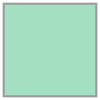

In [11]:
row[1]

In [ ]:
FeatureFolder = r""
RasterFolder = r""
OutputFolder = r""
arcpy.env.workspace = FeatureFolder
arcpy.env.overwriteOutput = True
l = arcpy.ListFeatureClasses()
for i in range(len(l)):
    name = l[i].split(".shp")[0]
    raster = name + ".tif"
    shutil.copy(RasterFolder + '/' + raster, OutputFolder + "\\" + raster)

In [ ]:
arcpy.da.SearchCursor(BoundaryFeature,["ID","SHAPE@"]) as cursor:

In [11]:
fishnet = r"E:\毕业论文\研究生毕业论文\基本数据\山体范围\高山区范围_渔网.shp"
RasterNames = []
with arcpy.da.UpdateCursor(fishnet,["X_min","Y_min","name"]) as cursor:
    for row in cursor:
        if row[1] >= 0 and row[0] >= 0:
            Lat = "N"
            Lon = "E"
            if len(str(abs(row[1]))) == 2:
                c1 = "0"
            elif len(str(abs(row[1]))) == 1:
                c1 = "00"
            else:
                c1 = ""
            if len(str(abs(row[0]))) == 2:
                c2 = "0"
            elif len(str(abs(row[0]))) == 1:
                c2 = "00"
            else:
                c2 = ""   
            Location = Lat + c1 + str(row[1]) + Lon + c2 + str(row[0]) + "_Proj.tif"
            RasterNames.append(Location)
            row[2] = Location
            cursor.updateRow(row)
        elif row[1] >= 0 and row[0] < 0:
            Lat = "N"
            Lon = "W"
            if len(str(abs(row[1]))) == 2:
                c1 = "0"
            elif len(str(abs(row[1]))) == 1:
                c1 = "00"
            else:
                c1 = ""
            if len(str(abs(row[0]))) == 2:
                c2 = "0"
            elif len(str(abs(row[0]))) == 1:
                c2 = "00"
            else:
                c2 = ""   
            Location = Lat + c1 + str(row[1]) + Lon + c2 + str(row[0] * -1) + "_Proj.tif"
            RasterNames.append(Location)
            row[2] = Location
            cursor.updateRow(row)
        elif row[1] < 0 and row[0] < 0:
            Lat = "S"
            Lon = "W"
            if len(str(abs(row[1]))) == 2:
                c1 = "0"
            elif len(str(abs(row[1]))) == 1:
                c1 = "00"
            else:
                c1 = ""
            if len(str(abs(row[0]))) == 2:
                c2 = "0"
            elif len(str(abs(row[0]))) == 1:
                c2 = "00"
            else:
                c2 = ""   
            Location = Lat + c1 + str(row[1] * -1) + Lon + c2 + str(row[0] * -1) + "_Proj.tif"
            RasterNames.append(Location)
            row[2] = Location
            cursor.updateRow(row)
        elif row[1] < 0 and row[0] >= 0:
            Lat = "S"
            Lon = "E"
            if len(str(abs(row[1]))) == 2:
                c1 = "0"
            elif len(str(abs(row[1]))) == 1:
                c1 = "00"
            else:
                c1 = ""
            if len(str(abs(row[0]))) == 2:
                c2 = "0"
            elif len(str(abs(row[0]))) == 1:
                c2 = "00"
            else:
                c2 = ""   
            Location = Lat + c1 + str(row[1] * -1) + Lon + c2 + str(row[0]) + "_Proj.tif"
            RasterNames.append(Location)
            row[2] = Location
            cursor.updateRow(row)
            

In [14]:
OutputPath = r"F:\高山区DEM"
FeatureWithRasterName = r"E:\毕业论文\研究生毕业论文\基本数据\山体范围\Boundary_渔网_Intersection.shp"
Folder = r"G:\GBLU全球基本地貌类型数据\FAB_projectDEM"
Folders = GetAllDir(Folder)
with arcpy.da.UpdateCursor(FeatureWithRasterName,["name"]) as cursor:
    for row in cursor:
        for f in Folders:
            if os.path.exists(f + "\\" + row[0]):
                shutil.copy(f + "\\" + row[0], OutputPath + "\\" + row[0])

In [13]:
os.path.exists(Folder)

['G:\\GBLU全球基本地貌类型数据\\FAB_projectDEM\\DSM469-532',
 'G:\\GBLU全球基本地貌类型数据\\FAB_projectDEM\\1-72',
 'G:\\GBLU全球基本地貌类型数据\\FAB_projectDEM\\73-108',
 'G:\\GBLU全球基本地貌类型数据\\FAB_projectDEM\\109-144',
 'G:\\GBLU全球基本地貌类型数据\\FAB_projectDEM\\145-180',
 'G:\\GBLU全球基本地貌类型数据\\FAB_projectDEM\\190-216',
 'G:\\GBLU全球基本地貌类型数据\\FAB_projectDEM\\217-252',
 'G:\\GBLU全球基本地貌类型数据\\FAB_projectDEM\\255-323',
 'G:\\GBLU全球基本地貌类型数据\\FAB_projectDEM\\330-353',
 'G:\\GBLU全球基本地貌类型数据\\FAB_projectDEM\\366-394',
 'G:\\GBLU全球基本地貌类型数据\\FAB_projectDEM\\397-432',
 'G:\\GBLU全球基本地貌类型数据\\FAB_projectDEM\\433-468']

In [7]:
s = ""
b = "ll"
s + b

'll'

In [8]:
len(s)

0